## Importando as Bibliotecas

In [1]:
# ================================
# Utilitários
# ================================
import time
import joblib
import duckdb

# ================================
# Manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Divisão, validação e otimização
# ================================
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_validate,
    StratifiedKFold,
    cross_val_score,
    learning_curve
)

# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

import xgboost as xgb

# ================================
# Avaliação de modelos
# ================================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

# ================================
# Interpretabilidade
# ================================
import shap
import optuna
import optuna.visualization as viz

print("Bibliotecas importadas com sucesso!!")

Bibliotecas importadas com sucesso!!


## Leitura da Base de Dados

In [2]:
dados = pd.read_csv("../data/dados_housing.csv")
dados.head()

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_media,valor_media_imovel,proximidade_oceano
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,proximo_baia
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,proximo_baia
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,proximo_baia
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,proximo_baia
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,proximo_baia


## Validação rápida dos Dados

In [3]:
print(f"Total de Linhas -> {dados.shape[0]}")
print(f"Total de Colunas -> {dados.shape[1]}")

Total de Linhas -> 20640
Total de Colunas -> 10


In [4]:
print(dados.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longitude              20640 non-null  float64
 1   latitude               20640 non-null  float64
 2   idade_mediana_imoveis  20640 non-null  float64
 3   total_comodos          20640 non-null  float64
 4   total_quartos          20433 non-null  float64
 5   populacao              20640 non-null  float64
 6   domicilios             20640 non-null  float64
 7   renda_media            20640 non-null  float64
 8   valor_media_imovel     20640 non-null  float64
 9   proximidade_oceano     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [5]:
# Mostrando os Dados Nulos
print(dados.isna().sum())

longitude                  0
latitude                   0
idade_mediana_imoveis      0
total_comodos              0
total_quartos            207
populacao                  0
domicilios                 0
renda_media                0
valor_media_imovel         0
proximidade_oceano         0
dtype: int64


## Criando Variável para fazer Estratificação

In [6]:
dados["faixa_preco"] = pd.qcut(
    dados["valor_media_imovel"],
    q=5,
    labels=False
)

In [7]:
dados["faixa_preco"].value_counts()

faixa_preco
2    4132
1    4129
0    4129
4    4125
3    4125
Name: count, dtype: int64

## Divisão em X e Y - Separando Dados

In [8]:
X = dados.drop("valor_media_imovel", axis=1)
y = dados["valor_media_imovel"]
estrato = dados["faixa_preco"]

In [9]:
# 1º Divisão -> treino + validação e Teste
X_temp, X_teste, y_temp, y_teste, estrato_temp, estrato_teste = train_test_split(X, y, estrato, test_size=0.20, random_state=42, stratify=estrato)

# 2º Divisão -> treino e validação
X_treino, X_val, y_treino, y_val, estrato_treino, estrato_val = train_test_split(X_temp, y_temp, estrato_temp, test_size=0.25, random_state=42, stratify=estrato_temp)

In [10]:
print(f"Treino: {len(X_treino) / len(dados):.2%}")
print(f"Validação: {len(X_val) / len(dados):.2%}")
print(f"Teste: {len(X_teste) / len(dados):.2%}")

Treino: 60.00%
Validação: 20.00%
Teste: 20.00%


In [11]:
print(X_treino["faixa_preco"].value_counts())
print(X_val["faixa_preco"].value_counts())
print(X_teste["faixa_preco"].value_counts())

faixa_preco
2    2480
0    2477
1    2477
4    2475
3    2475
Name: count, dtype: int64
faixa_preco
2    826
0    826
1    826
4    825
3    825
Name: count, dtype: int64
faixa_preco
2    826
0    826
1    826
3    825
4    825
Name: count, dtype: int64


In [12]:
X_treino = X_treino.drop("faixa_preco", axis=1)
X_val = X_val.drop("faixa_preco", axis=1)
X_teste = X_teste.drop("faixa_preco", axis=1)

## Criando colunas do Feature Engineering

In [13]:
def criar_colunas(df):
    df = df.copy()
    df["comodos_por_domicilio"] = df["total_comodos"] / df["domicilios"]
    df["quartos_por_comodo"] = df["total_quartos"] / df["total_comodos"]

    return df

In [14]:
X_treino_fe = criar_colunas(X_treino)
X_teste_fe = criar_colunas(X_teste)
X_val_fe = criar_colunas(X_val)

## Pré-processamento dos Dados

In [15]:
col_numericas = ['idade_mediana_imoveis', 'total_comodos', 'total_quartos', 'populacao', 'domicilios', 'renda_media']
col_categoricas = ['proximidade_oceano']

col_numericas_fe = ['idade_mediana_imoveis', 'total_comodos', 'total_quartos', 'populacao', 'domicilios', 'renda_media',
                     'comodos_por_domicilio', 'quartos_por_comodo']

In [16]:
pipeline_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [17]:
pipeline_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", sparse_output=False))
    ]
)

In [18]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, col_numericas),
        ("cat", pipeline_categorico, col_categoricas)
    ],
    remainder="passthrough"
)

X_treino_tratado = preprocessador.fit_transform(X_treino)
X_val_tratado = preprocessador.transform(X_val)
X_teste_tratado = preprocessador.transform(X_teste)

In [19]:
preprocessador_fe = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, col_numericas_fe),
        ("cat", pipeline_categorico, col_categoricas)
    ],
    remainder="passthrough"
)

X_treino_fe_tratado = preprocessador_fe.fit_transform(X_treino_fe)
X_val_fe_tratado = preprocessador_fe.transform(X_val_fe)
X_teste_fe_tratado = preprocessador_fe.transform(X_teste_fe)

In [20]:
num_cols = list(col_numericas)
cat_cols = preprocessador.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(col_categoricas).tolist()

X_treino = pd.DataFrame(X_treino_tratado, columns=(num_cols) + (cat_cols) + ["latitude"] + ["longitude"])
X_teste = pd.DataFrame(X_teste_tratado, columns=(num_cols) + (cat_cols) + ["latitude"] + ["longitude"])
X_val = pd.DataFrame(X_val_tratado, columns=(num_cols) + (cat_cols) + ["latitude"] + ["longitude"])

In [21]:
num_cols_fe = list(col_numericas_fe)
cat_cols = preprocessador.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(col_categoricas).tolist()

X_treino_fe = pd.DataFrame(X_treino_fe_tratado, columns=(num_cols_fe) + (cat_cols) + ["latitude"] + ["longitude"])
X_teste_fe = pd.DataFrame(X_teste_fe_tratado, columns=(num_cols_fe) + (cat_cols) + ["latitude"] + ["longitude"])
X_val_fe = pd.DataFrame(X_val_fe_tratado, columns=(num_cols_fe) + (cat_cols) + ["latitude"] + ["longitude"])

In [22]:
X_treino.head()

,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_media,proximidade_oceano_interior,proximidade_oceano_menos_1h_oceano,proximidade_oceano_proximo_baia,proximidade_oceano_proximo_oceano,latitude,longitude
0,-0.843499,-1.052519,-1.099944,-1.108935,-1.133174,-1.399217,1.0,0.0,0.0,0.0,-120.54,37.68
1,1.870922,-0.663041,0.300097,-0.372001,0.328918,-1.279084,0.0,0.0,1.0,0.0,-122.40,37.79
2,-1.402350,0.569084,0.072350,0.227096,0.126434,1.194674,0.0,1.0,0.0,0.0,-116.80,32.80
3,0.034696,-0.137017,0.007622,-0.270199,0.110656,-0.778840,0.0,0.0,1.0,0.0,-122.09,37.68
4,-1.322514,2.044976,1.738494,-0.217046,0.189546,0.560171,1.0,0.0,0.0,0.0,-116.42,33.79


In [23]:
X_treino_fe.head()

,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_media,comodos_por_domicilio,quartos_por_comodo,proximidade_oceano_interior,proximidade_oceano_menos_1h_oceano,proximidade_oceano_proximo_baia,proximidade_oceano_proximo_oceano,latitude,longitude
0,-0.843499,-1.052519,-1.099944,-1.108935,-1.133174,-1.399217,-0.177517,0.236069,1.0,0.0,0.0,0.0,-120.54,37.68
1,1.870922,-0.663041,0.300097,-0.372001,0.328918,-1.279084,-1.459991,5.824336,0.0,0.0,1.0,0.0,-122.40,37.79
2,-1.402350,0.569084,0.072350,0.227096,0.126434,1.194674,0.689869,-1.135562,0.0,1.0,0.0,0.0,-116.80,32.80
3,0.034696,-0.137017,0.007622,-0.270199,0.110656,-0.778840,-0.458870,0.299362,0.0,0.0,1.0,0.0,-122.09,37.68
4,-1.322514,2.044976,1.738494,-0.217046,0.189546,0.560171,2.905542,-0.598131,1.0,0.0,0.0,0.0,-116.42,33.79


## Aplicação do VarianceThreshold

In [24]:
selector_variance = VarianceThreshold(threshold=0.05)

X_treino_variance = selector_variance.fit_transform(X_treino)
X_val_variance = selector_variance.transform(X_val)
X_teste_variance = selector_variance.transform(X_teste)

features_variance = X_treino.columns[selector_variance.get_support()]

print(f"Features Originais -> {X_treino.shape[1]}")
print(f"Features Selecionadas -> {len(features_variance)}")

print("\nFeatures Selecionadas:")
print(features_variance.tolist())

Features Originais -> 12
Features Selecionadas -> 12

Features Selecionadas:
['idade_mediana_imoveis', 'total_comodos', 'total_quartos', 'populacao', 'domicilios', 'renda_media', 'proximidade_oceano_interior', 'proximidade_oceano_menos_1h_oceano', 'proximidade_oceano_proximo_baia', 'proximidade_oceano_proximo_oceano', 'latitude', 'longitude']


## Treinamento e comparação inicial dos modelos

In [25]:
modelos_regressao = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": xgb.XGBRegressor(n_estimators=300, max_depth=5, random_state=42)
}

### Modelos Sem Feature Engineering

In [26]:
resultados = []

for nome, modelo in modelos_regressao.items():
    modelo.fit(X_treino, y_treino)
    y_pred = modelo.predict(X_val)

    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mape = mean_absolute_percentage_error(y_val, y_pred)

    resultados.append({
        "Modelo": nome,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="MAE", ascending=True)
resultados_df.round(3)

,Modelo,R²,MAE,RMSE,MAPE
4,XGBoost,0.824,31456.840,48422.717,0.179
3,KNN,0.731,39440.081,59826.365,0.216
2,Random Forest,0.642,48602.017,68987.062,0.279
0,Regressão Linear,0.627,50026.667,70478.704,0.289
1,Árvore de Decisão,0.617,50335.893,71365.781,0.289


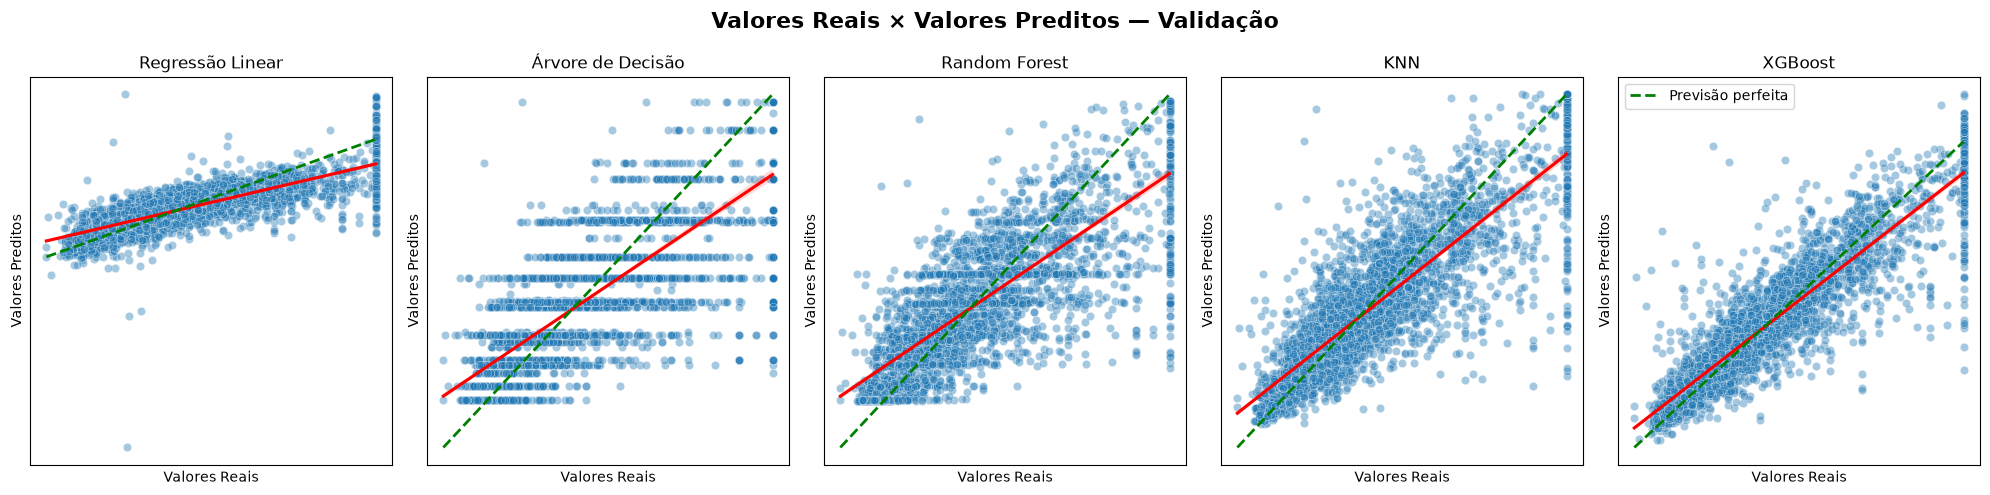

In [27]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (nome, modelo) in zip(axes, modelos_regressao.items()):
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_val)

    sns.scatterplot(x=y_val, y=pred, ax=ax, alpha=0.4)
    sns.regplot(x=y_val, y=pred, ax=ax, scatter=False, color="red")
    ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color="green", linestyle="--", linewidth=2, label="Previsão perfeita")

    ax.set_title(nome)
    ax.set_xlabel("Valores Reais")
    ax.set_ylabel("Valores Preditos")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(alpha=0.2)


fig.suptitle("Valores Reais × Valores Preditos — Validação", fontsize=16, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

### Modelos com Feature Engineering

In [28]:
resultados_fe = []

for nome, modelo in modelos_regressao.items():
    modelo.fit(X_treino_fe, y_treino)
    y_pred = modelo.predict(X_val_fe)

    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mape = mean_absolute_percentage_error(y_val, y_pred)

    resultados_fe.append({
        "Modelo": nome,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

resultados_fe_df = pd.DataFrame(resultados_fe).sort_values(by="MAE", ascending=True)
resultados_fe_df.round(3)

,Modelo,R²,MAE,RMSE,MAPE
4,XGBoost,0.829,31021.523,47706.857,0.177
3,KNN,0.721,40234.475,60912.261,0.220
2,Random Forest,0.644,48537.880,68831.690,0.278
0,Regressão Linear,0.633,49235.603,69850.750,0.287
1,Árvore de Decisão,0.617,50529.085,71385.804,0.287


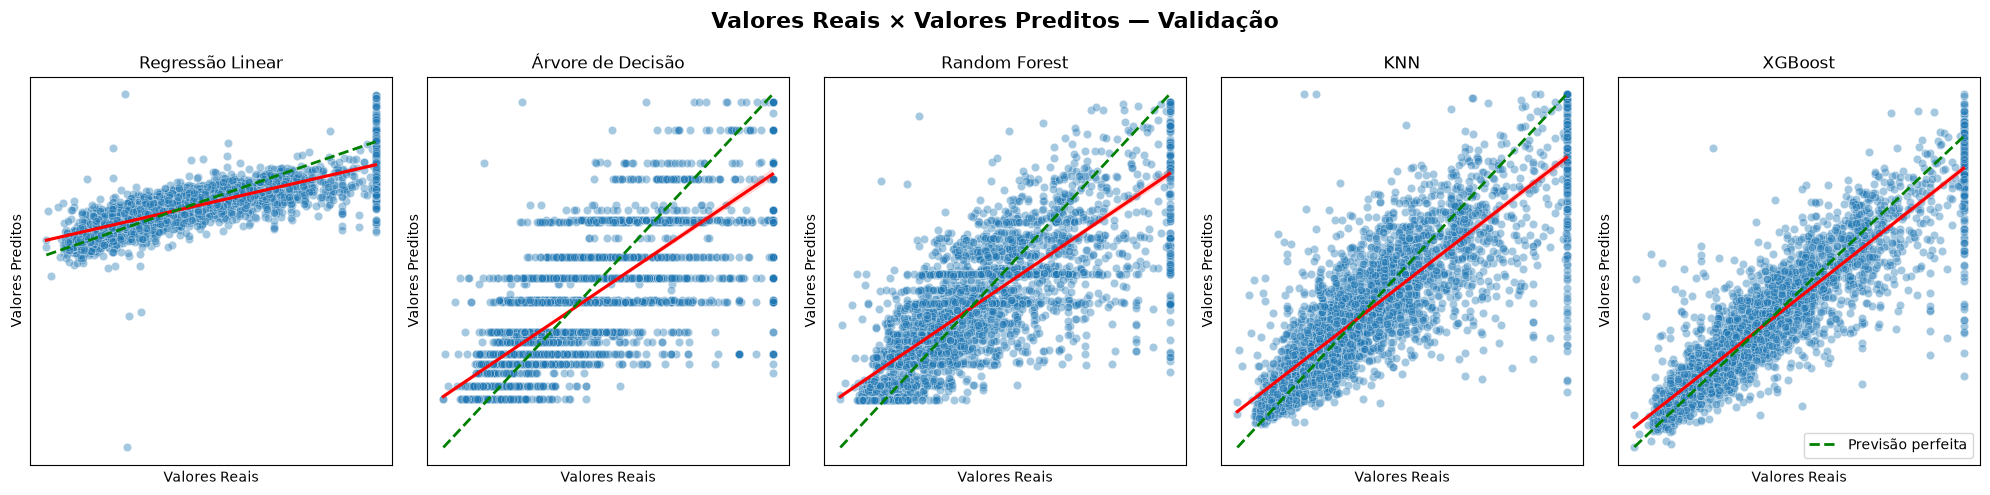

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (nome, modelo) in zip(axes, modelos_regressao.items()):
    modelo.fit(X_treino_fe, y_treino)
    pred = modelo.predict(X_val_fe)

    sns.scatterplot(x=y_val, y=pred, ax=ax, alpha=0.4)
    sns.regplot(x=y_val, y=pred, ax=ax, scatter=False, color="red")
    ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color="green", linestyle="--", linewidth=2, label="Previsão perfeita")

    ax.set_title(nome)
    ax.set_xlabel("Valores Reais")
    ax.set_ylabel("Valores Preditos")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(alpha=0.2)

axes[-1].legend(loc="lower right")

fig.suptitle("Valores Reais × Valores Preditos — Validação", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

## Otimização dos Hiperparâmetros - RandomizedSearchCV

In [30]:
xgb_model = xgb.XGBRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42)
knn_model = KNeighborsRegressor()

In [31]:
# Params XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5, 1],
    # Regularização L1
    "reg_alpha": [0, 0.01, 0.1, 1],
    # Regularização L2
    "reg_lambda": [0.1, 1, 5, 10]
}
# Params Random Forest
param_dist_rf = {
    "n_estimators": [200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}
# KNN
param_dist_knn = {
    "n_neighbors": [5, 10, 15, 20],
    "weights": ["uniform", "distance"],
    "p": [1, 2],
    "leaf_size": [20, 30, 40]
}

In [32]:
random_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_knn = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_dist_knn,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [33]:
inicio = time.perf_counter()
random_xgb.fit(X_treino_fe, y_treino)
tempo_xgb = time.perf_counter() - inicio

inicio = time.perf_counter()
random_rf.fit(X_treino_fe, y_treino)
tempo_rf = time.perf_counter() - inicio

inicio = time.perf_counter()
random_knn.fit(X_treino_fe, y_treino)
tempo_knn = time.perf_counter() - inicio

print("XGBoost - melhores Hiperparametros")
print(random_xgb.best_params_)
print("\nRandom Forest - melhores Hiperparametros")
print(random_rf.best_params_)
print("\nKNN - melhores Hiperparametros")
print(random_knn.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
XGBoost - melhores Hiperparametros
{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.8}

Random Forest - melhores Hiperparametros
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}

KNN - melhores Hiperparametros
{'weights': 'distance', 'p': 1, 'n_neighbors': 10, 'leaf_size': 40}


In [34]:
modelos_tunados = {
    "XGBoost Tunado": random_xgb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "KNN Tunado": random_knn.best_estimator_
}

resultados = []

for nome, modelo in modelos_tunados.items():
    pred = modelo.predict(X_val_fe)

    r2 = r2_score(y_val, pred)
    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mape = mean_absolute_percentage_error(y_val, pred)

    resultados.append({
        "Modelo": nome,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

resultados_tunados = pd.DataFrame(resultados).sort_values(by="MAE", ascending=True)

print(f"Tempo XGBoost -> {tempo_xgb:.2f} segundos")
print(f"Tempo Random Forest -> {tempo_rf:.2f} segundos")
print(f"Tempo KNN -> {tempo_knn:.2f} segundos")

resultados_tunados.round(3)

Tempo XGBoost -> 30.76 segundos
Tempo Random Forest -> 192.68 segundos
Tempo KNN -> 10.42 segundos


,Modelo,R²,MAE,RMSE,MAPE
0,XGBoost Tunado,0.817,32446.675,49363.661,0.184
1,Random Forest Tunado,0.801,33755.436,51488.624,0.193
2,KNN Tunado,0.745,38501.112,58256.731,0.211


## Modelo Ensemble - Voting Regressor

In [35]:
modelo_xgb_tunado = random_xgb.best_estimator_
modelo_rf_tunado = random_rf.best_estimator_
modelo_knn_tunado = random_knn.best_estimator_

In [36]:
modelo_voting = VotingRegressor(
    estimators=[
        ("xgboost", modelo_xgb_tunado),
        ("random_forest", modelo_rf_tunado)
    ],
    n_jobs=-1
)

In [37]:
modelo_voting.fit(X_treino_fe, y_treino)
pred_voting = modelo_voting.predict(X_val_fe)

resultado_voting = {
    "Modelo": "Modelo Voting",
    "R²": r2_score(y_val, pred_voting),
    "MAE": mean_absolute_error(y_val, pred_voting),
    "RMSE": np.sqrt(mean_squared_error(y_val, pred_voting)),
    "MAPE": mean_absolute_percentage_error(y_val, pred_voting)
}

resultado_voting_df = pd.DataFrame([resultado_voting])
resultado_voting_df.round(3)

,Modelo,R²,MAE,RMSE,MAPE
0,Modelo Voting,0.818,31980.611,49174.157,0.182


## Modelo Ensemble - Stacking Regressor

In [38]:
modelo_stacking = StackingRegressor(
    estimators=[
        ("XGBoost", modelo_xgb_tunado),
        ("Random_forest", modelo_rf_tunado),
        ("KNN", modelo_knn_tunado)
    ],
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

In [39]:
modelo_stacking.fit(X_treino_fe, y_treino)
pred_stacking = modelo_stacking.predict(X_val_fe)

resultado_stacking = {
    "Modelo": "Modelo Stacking",
    "R²": r2_score(y_val, pred_stacking),
    "MAE": mean_absolute_error(y_val, pred_stacking),
    "RMSE": np.sqrt(mean_squared_error(y_val, pred_stacking)),
    "MAPE": mean_absolute_percentage_error(y_val, pred_stacking)
}

resultado_stacking_df = pd.DataFrame([resultado_stacking])
resultado_stacking_df.round(3)

,Modelo,R²,MAE,RMSE,MAPE
0,Modelo Stacking,0.822,31635.354,48725.783,0.177


## Comparação dos Modelos

In [40]:
resultado_final = pd.concat([resultados_fe_df, resultados_tunados, resultado_voting_df, resultado_stacking_df])
resultado_final = resultado_final.sort_values(by="MAE", ascending=True)
resultado_final.round(3)

,Modelo,R²,MAE,RMSE,MAPE
4,XGBoost,0.829,31021.523,47706.857,0.177
0,Modelo Stacking,0.822,31635.354,48725.783,0.177
0,Modelo Voting,0.818,31980.611,49174.157,0.182
0,XGBoost Tunado,0.817,32446.675,49363.661,0.184
1,Random Forest Tunado,0.801,33755.436,51488.624,0.193
2,KNN Tunado,0.745,38501.112,58256.731,0.211
3,KNN,0.721,40234.475,60912.261,0.220
2,Random Forest,0.644,48537.880,68831.690,0.278
0,Regressão Linear,0.633,49235.603,69850.750,0.287
1,Árvore de Decisão,0.617,50529.085,71385.804,0.287


## Otimização - OPTUNA (30 iterações)

In [41]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 700),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.65, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 0.95),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 15.0)
    }

    modelo = xgb.XGBRegressor(**params, objective="reg:squarederror", random_state=42, n_jobs=1)

    score = cross_val_score(modelo, X_treino_fe, y_treino, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1).mean()

    return -score

In [42]:
sampler = optuna.samplers.TPESampler(seed=42)

study_xgb = optuna.create_study(
    direction="minimize",
    sampler=sampler
)

study_xgb.optimize(
    objective_xgb,
    n_trials=30
)

[I 2026-09-08 08:50:20,367] A new study created in memory with name: no-name-9d00e286-f48a-4900-ac73-6aefcc324e6d
[I 2026-09-08 08:50:23,211] Trial 0 finished with value: 32065.384925230996 and parameters: {'n_estimators': 387, 'learning_rate': 0.08927180304353628, 'max_depth': 5, 'min_child_weight': 8, 'subsample': 0.696805592132731, 'colsample_bytree': 0.6967983561008608, 'gamma': 0.05808361216819946, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 9.415610164404923}. Best is trial 0 with value: 32065.384925230996.
[I 2026-09-08 08:50:28,346] Trial 1 finished with value: 34426.32452100304 and parameters: {'n_estimators': 554, 'learning_rate': 0.010485387725194618, 'max_depth': 6, 'min_child_weight': 11, 'subsample': 0.7137017332034828, 'colsample_bytree': 0.7045474901621303, 'gamma': 0.18340450985343382, 'reg_alpha': 0.6084844859190754, 'reg_lambda': 8.346590042851329}. Best is trial 0 with value: 32065.384925230996.
[I 2026-09-08 08:50:31,915] Trial 2 finished with value: 34393.06333

In [43]:
print(f"Melhor MAE -> {study_xgb.best_value:.4f}")

print("\nMelhores Hiperparâmetros:")
print(study_xgb.best_params)

Melhor MAE -> 31303.7769

Melhores Hiperparâmetros:
{'n_estimators': 364, 'learning_rate': 0.07769309892445583, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.7180126374746866, 'colsample_bytree': 0.7419273026272744, 'gamma': 0.15933420206408683, 'reg_alpha': 1.1416272655297912, 'reg_lambda': 12.24019868980373}


In [44]:
modelo_xgb_optuna = xgb.XGBRegressor(**study_xgb.best_params, objective="reg:squarederror", random_state=42, n_jobs=-1)

modelo_xgb_optuna.fit(X_treino_fe, y_treino)

pred_optuna = modelo_xgb_optuna.predict(X_val_fe)

In [45]:
resultado_optuna = {
    "Modelo": "XGBoost Optuna",
    "R²": r2_score(y_val, pred_optuna),
    "MAE": mean_absolute_error(y_val, pred_optuna),
    "RMSE": np.sqrt(mean_squared_error(y_val, pred_optuna)),
    "MAPE": mean_absolute_percentage_error(y_val, pred_optuna)
}

resultado_optuna_df = pd.DataFrame([resultado_optuna])
resultado_optuna_df.round(3)

,Modelo,R²,MAE,RMSE,MAPE
0,XGBoost Optuna,0.832,30490.045,47314.925,0.173


In [46]:
fig1 = viz.plot_optimization_history(study_xgb, target_name="MAE")
fig1.show()

fig2 = viz.plot_param_importances(study_xgb, target_name="MAE")
fig2.show()

## Optuna - 50 Iterações

In [47]:
sampler = optuna.samplers.TPESampler(seed=42)

study_xgb_50 = optuna.create_study(
    direction="minimize",
    sampler=sampler
)

study_xgb_50.optimize(
    objective_xgb,
    n_trials=50
)

[I 2026-09-08 08:51:48,687] A new study created in memory with name: no-name-7c8694fa-a86c-4193-8519-8539f92210b5
[I 2026-09-08 08:51:51,514] Trial 0 finished with value: 32065.384925230996 and parameters: {'n_estimators': 387, 'learning_rate': 0.08927180304353628, 'max_depth': 5, 'min_child_weight': 8, 'subsample': 0.696805592132731, 'colsample_bytree': 0.6967983561008608, 'gamma': 0.05808361216819946, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 9.415610164404923}. Best is trial 0 with value: 32065.384925230996.
[I 2026-09-08 08:51:56,405] Trial 1 finished with value: 34426.32452100304 and parameters: {'n_estimators': 554, 'learning_rate': 0.010485387725194618, 'max_depth': 6, 'min_child_weight': 11, 'subsample': 0.7137017332034828, 'colsample_bytree': 0.7045474901621303, 'gamma': 0.18340450985343382, 'reg_alpha': 0.6084844859190754, 'reg_lambda': 8.346590042851329}. Best is trial 0 with value: 32065.384925230996.
[I 2026-09-08 08:51:59,700] Trial 2 finished with value: 34393.06333

In [48]:
print(f"Melhor MAE -> {study_xgb_50.best_value:.4f}")

print("\nMelhores Hiperparâmetros")
print(study_xgb_50.best_params)

Melhor MAE -> 31127.2642

Melhores Hiperparâmetros
{'n_estimators': 485, 'learning_rate': 0.053132900550269306, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.7318718826798571, 'colsample_bytree': 0.808118077195807, 'gamma': 0.11515808919480294, 'reg_alpha': 1.528079973005137, 'reg_lambda': 12.738681481487253}


In [49]:
fig1_200 = viz.plot_optimization_history(study_xgb_50, target_name="MAE")
fig1_200.show()

fig2_200 = viz.plot_param_importances(study_xgb_50, target_name="MAE")
fig2_200.show()

In [50]:
modelo_xgb_optuna_50 = xgb.XGBRegressor(**study_xgb_50.best_params, objective="reg:absoluteerror", random_state=42, n_jobs=-1)

modelo_xgb_optuna_50.fit(X_treino_fe, y_treino)

pred_optuna_50 = modelo_xgb_optuna.predict(X_val_fe)

In [51]:
resultado_optuna_50 = {
    "Modelo": "XGBoost Optuna - 50",
    "R²": r2_score(y_val, pred_optuna_50),
    "MAE": mean_absolute_error(y_val, pred_optuna_50),
    "RMSE": np.sqrt(mean_squared_error(y_val, pred_optuna_50)),
    "MAPE": mean_absolute_percentage_error(y_val, pred_optuna_50)
}

resultado_optuna_df_50 = pd.DataFrame([resultado_optuna_50])
resultado_optuna_df_50.round(3)

,Modelo,R²,MAE,RMSE,MAPE
0,XGBoost Optuna - 50,0.832,30490.045,47314.925,0.173


### Verificando todos os Resultados

In [52]:
resultados = pd.concat([resultado_final, resultado_optuna_df, resultado_optuna_df_50])
resultados = resultados.sort_values(by="MAE", ascending=True)
resultados.head(5).round(3)

,Modelo,R²,MAE,RMSE,MAPE
0,XGBoost Optuna,0.832,30490.045,47314.925,0.173
0,XGBoost Optuna - 50,0.832,30490.045,47314.925,0.173
4,XGBoost,0.829,31021.523,47706.857,0.177
0,Modelo Stacking,0.822,31635.354,48725.783,0.177
0,Modelo Voting,0.818,31980.611,49174.157,0.182


C:\Users\Unisalesiano\AppData\Local\Temp\ipykernel_7860\2041426203.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=resultados, x="MAE", y="Modelo", palette="coolwarm")


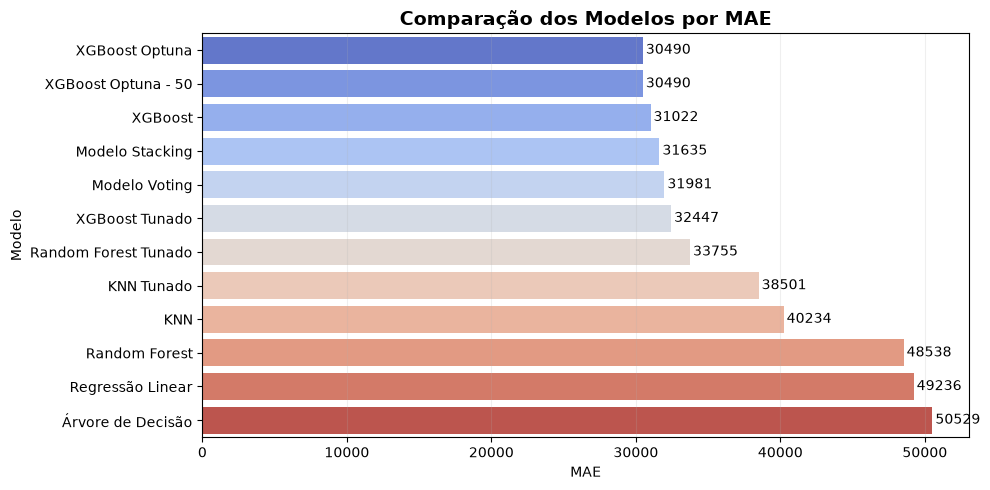

In [63]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(data=resultados, x="MAE", y="Modelo", palette="coolwarm")

for i, valor in enumerate(resultados["MAE"]):
    ax.text(valor + 200, i, f"{valor:.0f}", va="center")

plt.title("Comparação dos Modelos por MAE", fontsize=14, fontweight="bold")
plt.xlabel("MAE")
plt.ylabel("Modelo")
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

## Validação Cruzada - Modelo Final

In [54]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)

metricas = ["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error", "neg_mean_absolute_percentage_error"]

cv_resultados = cross_validate(modelo_xgb_optuna, X_treino_fe, y_treino, cv=cv, scoring=metricas, n_jobs=-1)

In [55]:
cv_df = pd.DataFrame({
    "Métrica": ["R²", "MAE", "RMSE", "MAPE (%)"],
    "Média": [
        cv_resultados["test_r2"].mean(),
        -cv_resultados["test_neg_mean_absolute_error"].mean(),
        -cv_resultados["test_neg_root_mean_squared_error"].mean(),
        -cv_resultados["test_neg_mean_absolute_percentage_error"].mean() * 100
    ],
    "Desvio Padrão": [
        cv_resultados["test_r2"].std(),
        cv_resultados["test_neg_mean_absolute_error"].std(),
        cv_resultados["test_neg_root_mean_squared_error"].std(),
        cv_resultados["test_neg_mean_absolute_percentage_error"].std() * 100
    ]
})

cv_df.round(3)

,Métrica,Média,Desvio Padrão
0,R²,0.838,0.008
1,MAE,31303.777,521.531
2,RMSE,46567.777,699.496
3,MAPE (%),17.348,0.335


## Verificando Overfitting com Learning Curve

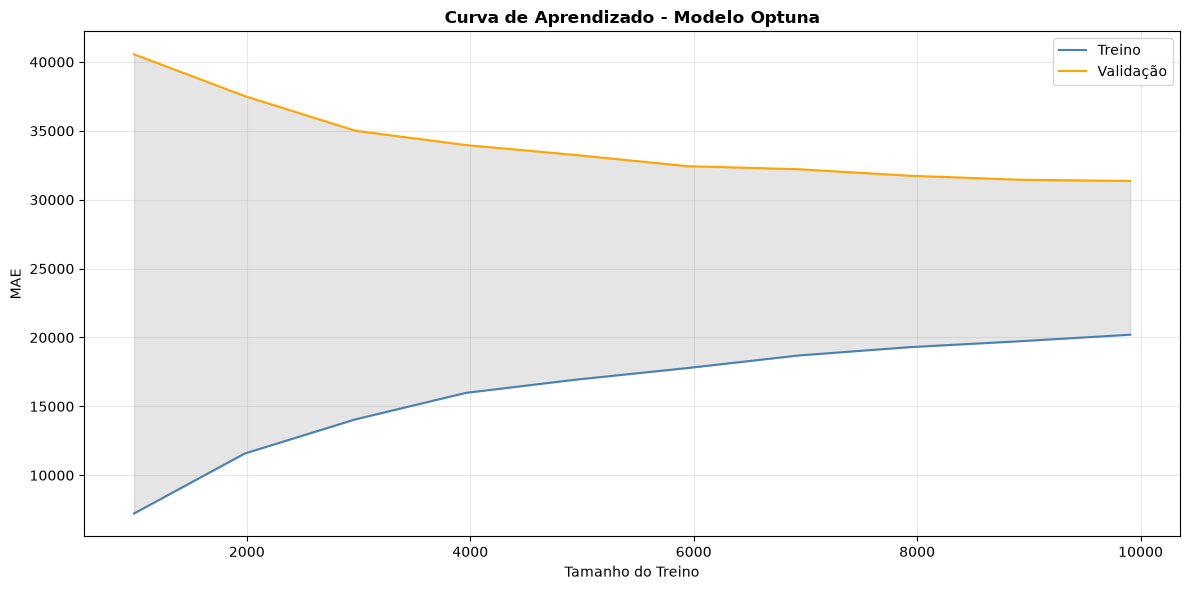

In [56]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, validation_scores = learning_curve(estimator=modelo_xgb_optuna, X=X_treino_fe, y=y_treino, cv=cv, train_sizes=np.linspace(0.1, 1.0, 10), scoring="neg_mean_absolute_error", n_jobs=-1)

train_mean = -train_scores.mean(axis=1)
val_mean = -validation_scores.mean(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean, label="Treino", color="steelblue")
plt.plot(train_sizes, val_mean, label="Validação", color="orange")
plt.fill_between(train_sizes, train_mean, val_mean, alpha=0.2, color="gray")

plt.title("Curva de Aprendizado - Modelo Optuna", fontweight="bold")
plt.xlabel("Tamanho do Treino")
plt.ylabel("MAE")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
gap_final = val_mean[-1] - train_mean[-1] 

print(f"MAE - Treino : {train_mean[-1]:.4f}")
print(f"MAE - Validação : {val_mean[-1]:.4f}")
print(f"GAP Final -> {gap_final:.4f}")

MAE - Treino : 20202.3495
MAE - Validação : 31362.8358
GAP Final -> 11160.4863


## Avaliação Modelo Final - Conjunto Teste

In [58]:
pred_final = modelo_xgb_optuna.predict(X_teste_fe)

resultados_teste = {
    "R²": r2_score(y_teste, pred_final),
    "MAE": mean_absolute_error(y_teste, pred_final),
    "RMSE": np.sqrt(mean_squared_error(y_teste, pred_final)),
    "MAPE": mean_absolute_percentage_error(y_teste, pred_final)
}

resultados_df_teste = pd.DataFrame([resultados_teste])
resultados_df_teste.round(3)

,R²,MAE,RMSE,MAPE
0,0.837,30407.059,46270.094,0.165


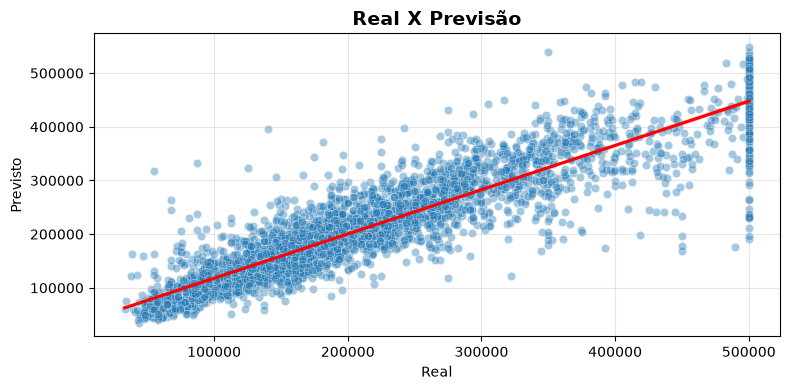

In [59]:
plt.figure(figsize=(8,4))

sns.scatterplot(x=y_teste, y=pred_final, alpha=0.4)
sns.regplot(x=y_teste, y=pred_final, scatter=False, color="red")

plt.title("Real X Previsão", fontsize=14, fontweight="bold")
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

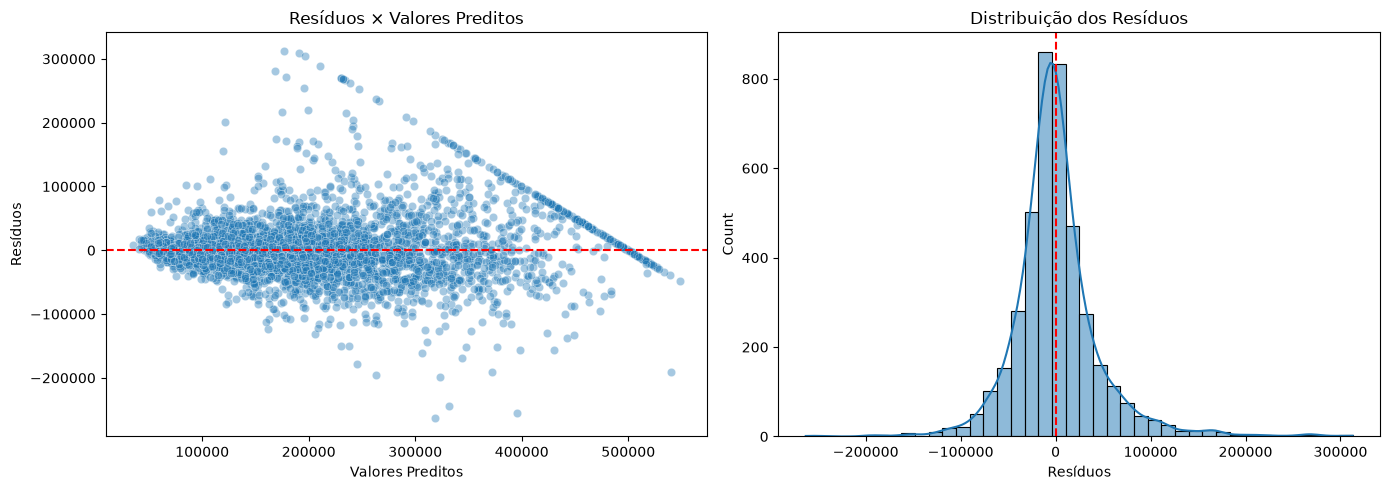

In [68]:
residuos = y_teste - pred_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=pred_final, y=residuos, alpha=0.4, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Resíduos × Valores Preditos")
axes[0].set_xlabel("Valores Preditos")
axes[0].set_ylabel("Resíduos")

sns.histplot(residuos, bins=40, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribuição dos Resíduos")
axes[1].set_xlabel("Resíduos")

plt.tight_layout()
plt.show()

## Feature Importance - Modelo Final

In [61]:
importance_xgb = pd.DataFrame({
    "feature": X_teste_fe.columns,
    "importance": modelo_xgb_optuna.feature_importances_
})

importance_xgb = importance_xgb.sort_values(by="importance", ascending=False)
print(importance_xgb)

                               feature  importance
8          proximidade_oceano_interior    0.378618
5                          renda_media    0.175744
10     proximidade_oceano_proximo_baia    0.100822
11   proximidade_oceano_proximo_oceano    0.073161
9   proximidade_oceano_menos_1h_oceano    0.069657
12                            latitude    0.037951
13                           longitude    0.031473
7                   quartos_por_comodo    0.028582
0                idade_mediana_imoveis    0.025588
6                comodos_por_domicilio    0.020760
3                            populacao    0.016477
2                        total_quartos    0.014460
4                           domicilios    0.013569
1                        total_comodos    0.013137


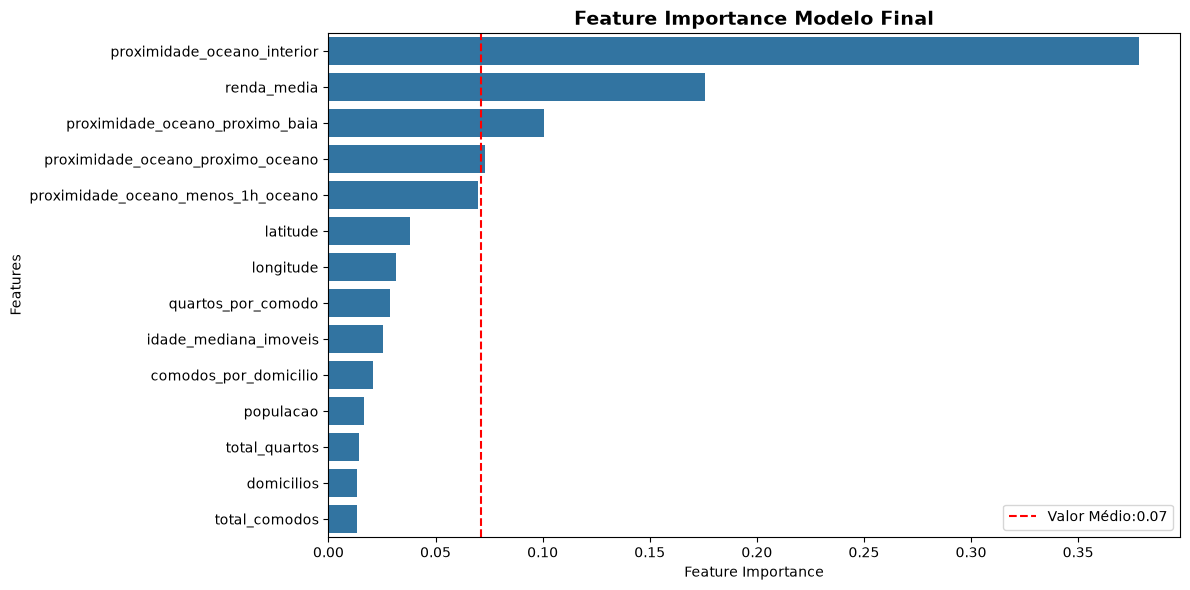

In [62]:
valor_medio = importance_xgb["importance"].mean()

plt.figure(figsize=(12,6))

sns.barplot(data=importance_xgb, x="importance", y="feature")
plt.axvline(importance_xgb["importance"].mean(), color="red", label=f"Valor Médio:{valor_medio:.2f}", linestyle='--')

plt.title("Feature Importance Modelo Final", fontsize=14, fontweight="bold")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.legend()
plt.tight_layout()
plt.show()

## Interpretabilidade do modelo com SHAP

In [69]:
explainer = shap.TreeExplainer(modelo_xgb_optuna)

shap_values = explainer.shap_values(X_teste_fe)

print(f"Shape X_teste: {X_teste_fe.shape}")
print(f"Shape SHAP: {np.asarray(shap_values).shape}")

Shape X_teste: (4128, 14)
Shape SHAP: (4128, 14)


## Importancia Global das Variáveis

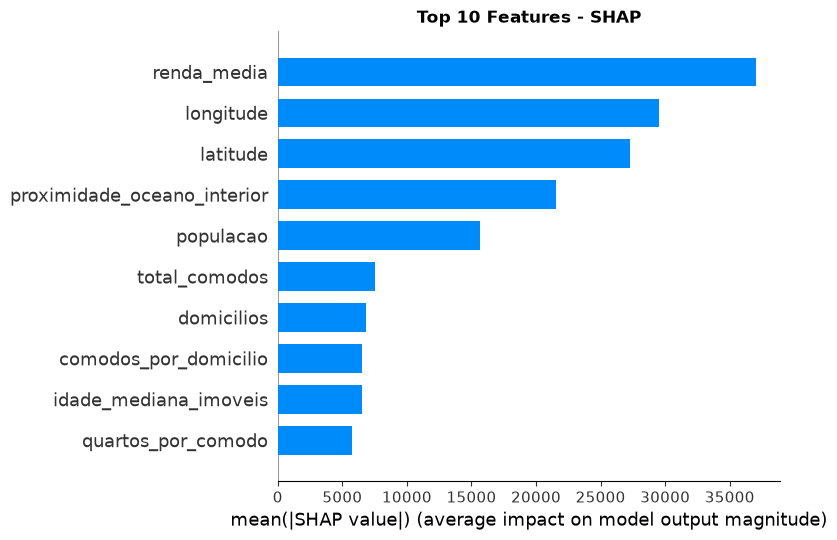

In [70]:
shap.summary_plot(
    shap_values,
    X_teste_fe,
    max_display=10,
    plot_type="bar",
    show=False
)

plt.title("Top 10 Features - SHAP", fontweight="bold")
plt.tight_layout()
plt.show()

## Distribuição e direção do impacto das features

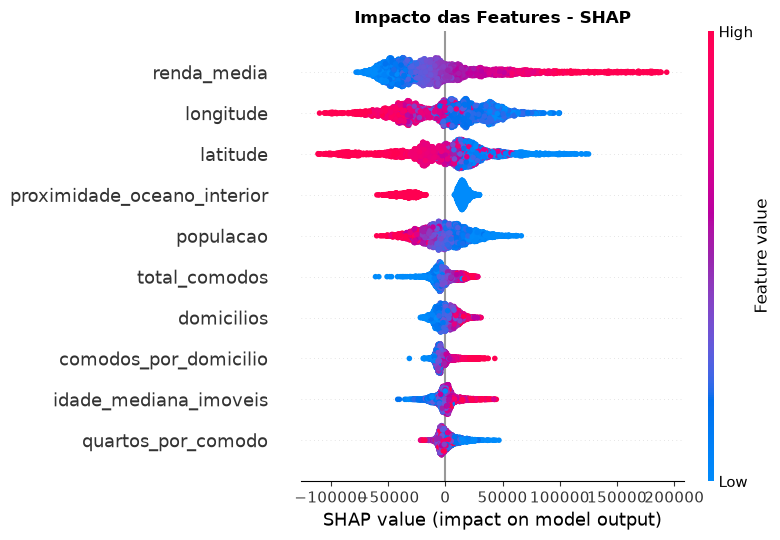

In [71]:
shap.summary_plot(
    shap_values,
    X_teste_fe,
    max_display=10,
    show=False
)

plt.title("Impacto das Features - SHAP", fontweight="bold")
plt.tight_layout()
plt.show()

### Análise de dependência das principais variáveis

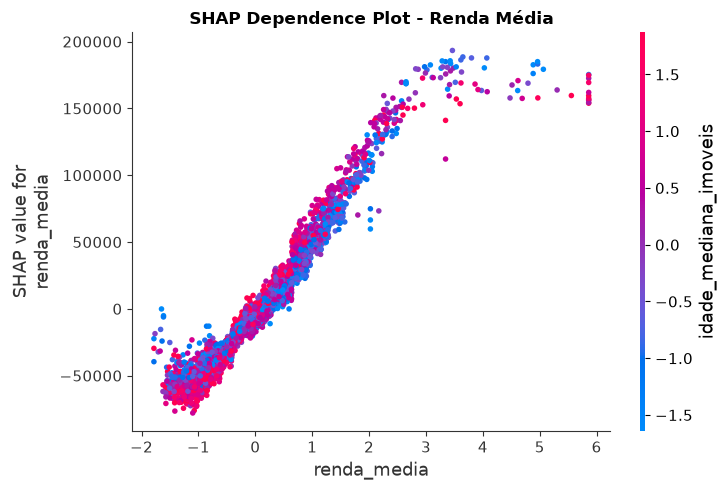

In [73]:
feature_dependence = "renda_media"

shap.dependence_plot(
    feature_dependence,
    shap_values,
    X_teste_fe,
    show=False
)
plt.title("SHAP Dependence Plot - Renda Média", fontweight="bold")
plt.tight_layout()
plt.show()


## Explicação Individual de uma previsão

Valor Real -> 176600.00
Valor Previsto -> 134593.39


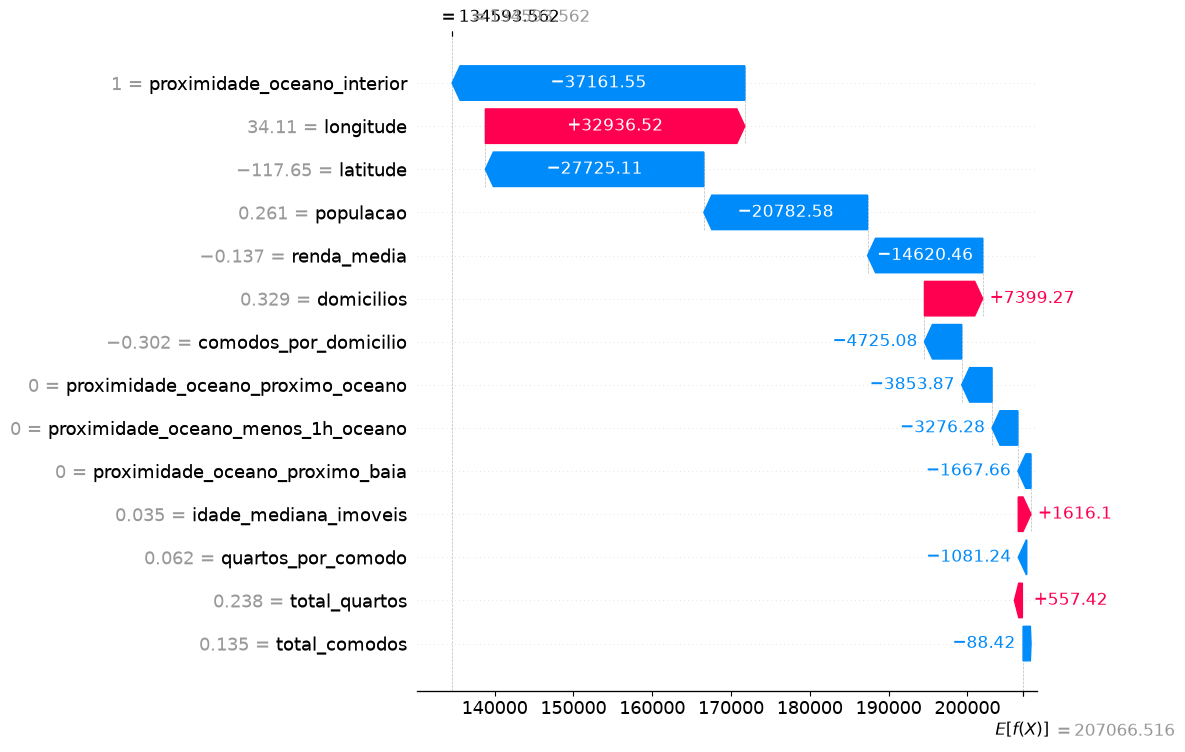

In [82]:
indice_imovel = 3

imovel_df = X_teste_fe.iloc[[indice_imovel]]
valor_real = y_teste.iloc[indice_imovel]
valor_previsto = modelo_xgb_optuna.predict(imovel_df)[0]

print(f"Valor Real -> {valor_real:.2f}")
print(f"Valor Previsto -> {valor_previsto:.2f}")

base_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])

explanation_cliente = shap.Explanation(
    values=shap_values[indice_imovel],
    base_values=base_value,
    data=imovel_df.iloc[0].values,
    feature_names=X_teste_fe.columns.tolist()
)

shap.plots.waterfall(explanation_cliente, max_display=14)

#  — Aplicação de Negócio

## Priorização Geográfica de Regiões Imobiliárias

Após a etapa de modelagem, o objetivo deste notebook é transformar o modelo em uma solução de apoio à decisão para análise regional do mercado imobiliário da Califórnia.

A proposta é utilizar as previsões do modelo para:

- estimar o valor mediano dos imóveis por região;
- segmentar o mercado em faixas de valor;
- identificar regiões compatíveis com um orçamento definido;
- visualizar espacialmente essas regiões por meio de longitude e latitude.

> Como o dataset representa regiões censitárias, a solução deve ser interpretada como uma ferramenta de análise regional e não como avaliação individual de imóveis.

## Base de Apoio à Decisão

Nesta etapa, as previsões do modelo são incorporadas à base original para formar uma tabela orientada ao negócio.

In [83]:
pred_teste = modelo_xgb_optuna.predict(X_teste_fe)

base_negocio = X_teste.copy()
base_negocio["valor_estimado"] = pred_teste

## Segmentação do Mercado

Para facilitar a leitura comercial, as regiões serão agrupadas em quatro segmentos de mercado com base no valor estimado pelo modelo.

In [84]:
base_negocio["segmento_mercado"] = pd.qcut(
    base_negocio["valor_estimado"],
    q=4,
    labels=["Econômico", "Intermediário", "Alto Padrão", "Premium"]
)

base_negocio[["valor_estimado", "segmento_mercado"]].head()

,valor_estimado,segmento_mercado
0,219057.328125,Alto Padrão
1,59032.175781,Econômico
2,231928.703125,Alto Padrão
3,134593.390625,Intermediário
4,427456.093750,Premium


## Mapa Analítico das Regiões

A visualização geográfica é uma das partes mais valiosas deste projeto, pois permite observar como o valor estimado se distribui espacialmente no território da Califórnia.

Cada ponto representa uma região, posicionada por longitude e latitude, e colorida de acordo com o valor estimado pelo modelo.

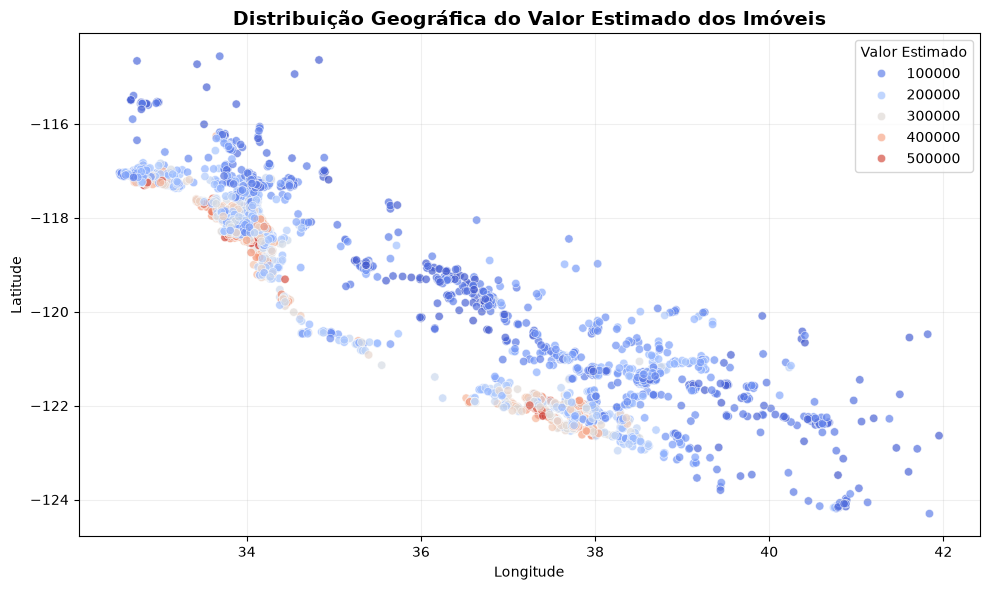

In [85]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=base_negocio, x="longitude", y="latitude", hue="valor_estimado", palette="coolwarm", alpha=0.7)

plt.title("Distribuição Geográfica do Valor Estimado dos Imóveis", fontsize=14, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.legend(title="Valor Estimado")

plt.tight_layout()
plt.show()

## Análise por Orçamento

Uma aplicação direta da solução é filtrar regiões compatíveis com um orçamento máximo definido.

Isso permite reduzir o universo de análise e direcionar esforços comerciais para regiões alinhadas ao perfil desejado.

In [103]:
orcamento_maximo = 400000

regioes_compativeis = base_negocio[base_negocio["valor_estimado"] <= orcamento_maximo].copy()

regioes_compativeis["margem_orcamento"] = (orcamento_maximo - regioes_compativeis["valor_estimado"])

regioes_compativeis = regioes_compativeis.sort_values(by="valor_estimado", ascending=False)

regioes_compativeis[
    ["longitude", "latitude", "renda_media", "valor_estimado", "segmento_mercado", "margem_orcamento"]
].head(10)

,longitude,latitude,renda_media,valor_estimado,segmento_mercado,margem_orcamento
165,33.61,-117.85,1.942827,399696.18750,Premium,303.81250
3140,37.85,-122.62,1.548746,399604.15625,Premium,395.84375
3071,37.80,-122.41,-0.145074,399520.25000,Premium,479.75000
4100,34.00,-118.48,-0.636832,398947.87500,Premium,1052.12500
3123,34.22,-118.18,1.108436,398377.40625,Premium,1622.59375
1486,34.45,-119.79,1.044654,398169.21875,Premium,1830.78125
1213,34.01,-118.48,0.109423,398024.96875,Premium,1975.03125
2001,33.95,-117.75,1.951525,397416.00000,Premium,2584.00000
4015,38.04,-122.59,2.363053,397315.40625,Premium,2684.59375
1842,34.21,-118.20,1.515695,396878.84375,Premium,3121.15625


## Mapa das Regiões Compatíveis com o Orçamento

O gráfico abaixo destaca apenas as regiões cujo valor estimado está dentro do orçamento definido.

Essa visualização pode apoiar a priorização comercial, a seleção de áreas de atuação e a análise de mercados-alvo.

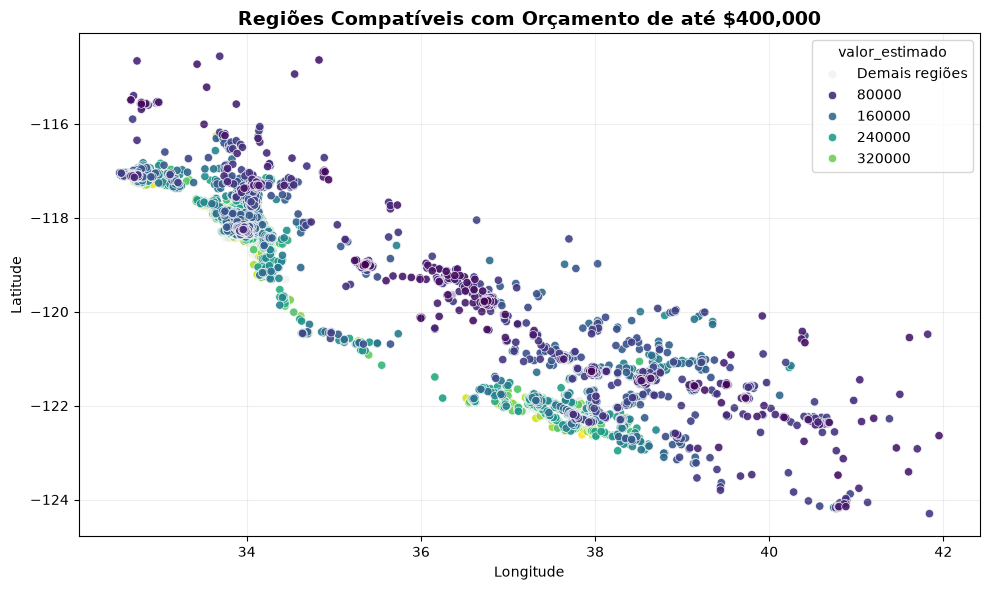

In [104]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=base_negocio, x="longitude", y="latitude", color="lightgray", alpha=0.25, label="Demais regiões")

sns.scatterplot(data=regioes_compativeis, x="longitude", y="latitude", hue="valor_estimado", palette="viridis", alpha=0.9)

plt.title(f"Regiões Compatíveis com Orçamento de até ${orcamento_maximo:,.0f}", fontsize=14, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Resumo da Análise

A seguir, são apresentados indicadores simples para apoiar a leitura de negócio das regiões selecionadas.

In [105]:
print(f"Orçamento máximo: ${orcamento_maximo:,.2f}")
print(f"Quantidade de regiões compatíveis: {len(regioes_compativeis)}")
print(f"Valor médio estimado: ${regioes_compativeis['valor_estimado'].mean():,.2f}")
print(f"Valor mediano estimado: ${regioes_compativeis['valor_estimado'].median():,.2f}")

Orçamento máximo: $400,000.00
Quantidade de regiões compatíveis: 3888
Valor médio estimado: $190,016.56
Valor mediano estimado: $180,691.34


## Interpretabilidade da Estimativa

Além da análise geográfica, o modelo também pode explicar individualmente por que determinada região recebeu uma estimativa maior ou menor, por meio do SHAP.

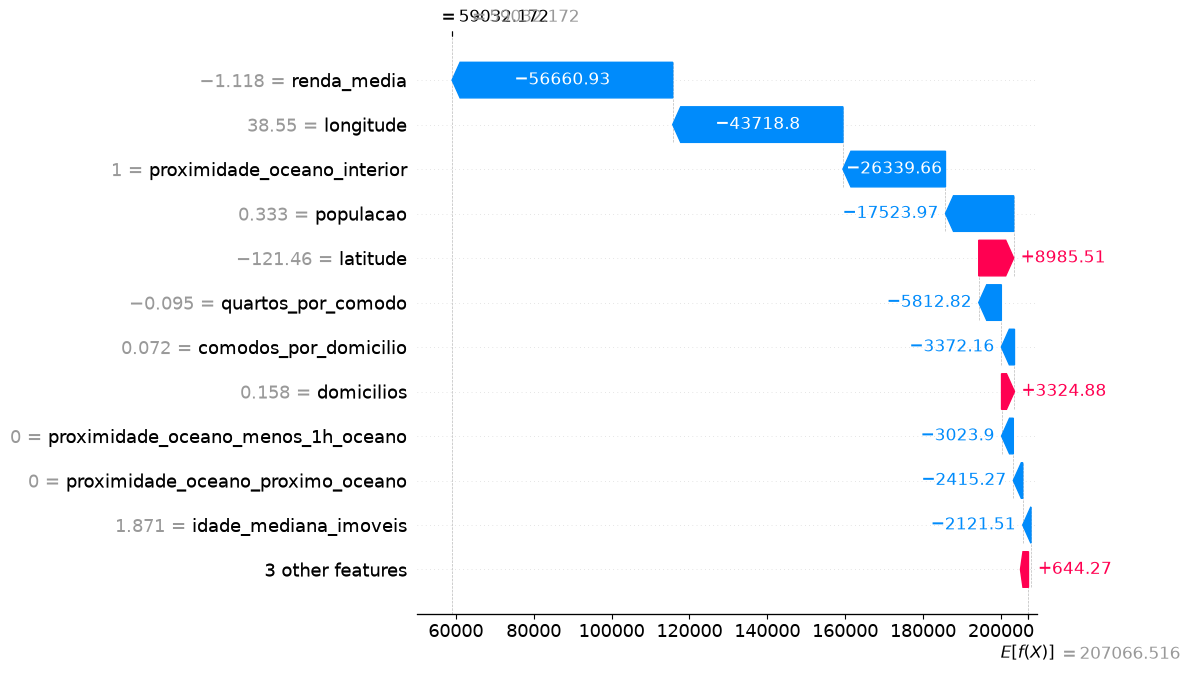

In [106]:
indice_imovel = 1
imovel_df = X_teste_fe.iloc[[indice_imovel]]

base_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])

explanation_cliente = shap.Explanation(
    values=shap_values[indice_imovel],
    base_values=base_value,
    data=imovel_df.iloc[0].values,
    feature_names=imovel_df.columns.tolist()
)

shap.plots.waterfall(explanation_cliente, max_display=12)

## Conclusão

A solução proposta transforma o modelo preditivo em uma ferramenta de apoio à decisão para o mercado imobiliário regional.

Com base nas previsões do modelo, foi possível:

- estimar o valor dos imóveis por região;
- segmentar o mercado em diferentes faixas;
- filtrar regiões compatíveis com um orçamento;
- visualizar espacialmente essas oportunidades com longitude e latitude;
- interpretar previsões individuais com SHAP.

A próxima etapa será transformar essa lógica em uma aplicação interativa com Streamlit.

## Salvamento do Pipeline Final

In [107]:
pipeline_final = Pipeline(
    steps=[
        ("preprocessador", preprocessador_fe),
        ("modelo_final", modelo_xgb_optuna)
    ]
)

In [108]:
joblib.dump(pipeline_final, "../models/pipeline_completo.pkl")

['../models/pipeline_completo.pkl']